In [ ]:
#This python notebook is for a hands-on tutorial on the conception of pulsar search, the material is developed by Jason Hessels
#The input file is a dedispersed timeseries from LOFAR of the original pulsar
#The data is provided by Ziggy Pleunis and Jason Hessels of U. Amsterdam and ASTRON

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage

#Read file to get the time series (ts)
ts = np.fromfile("L197621_SAP0_BEAM1_DM12.44_Mask.dat", dtype=np.float32)

#Check the length of the time series to find out the total number of samples. 
nsamp = 

#The sampling rate of this observation
tsamp = 0.00262143998406827

#The integration time (t)
t = np.arange(nsamp) * tsamp

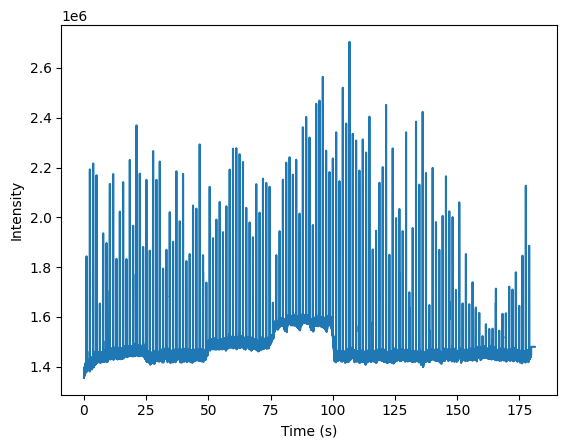

In [2]:
# check data
plt.plot(t, ts)
plt.ylabel("Intensity")
plt.xlabel("Time (s)")
plt.show()


Text(0.5, 0, 'Time (s)')

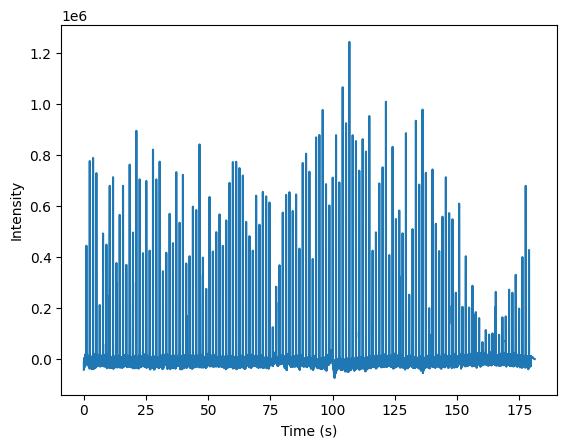

In [7]:
# The baseline of this time series is not flat, we will need to filter out this red noise
# Hint: use scipy.ndimage.uniform_filter1d to calculate a running mean in order to normalize the data
# Hint: need to play with window size when data and/or tsamp changes

running_mean = 
normalized = 
plt.plot(t, normalized)
plt.ylabel("Intensity")
plt.xlabel("Time (s)")

/opt/homebrew/Caskroom/miniconda/base/envs/vri/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/homebrew/Caskroom/miniconda/base/envs/vri/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


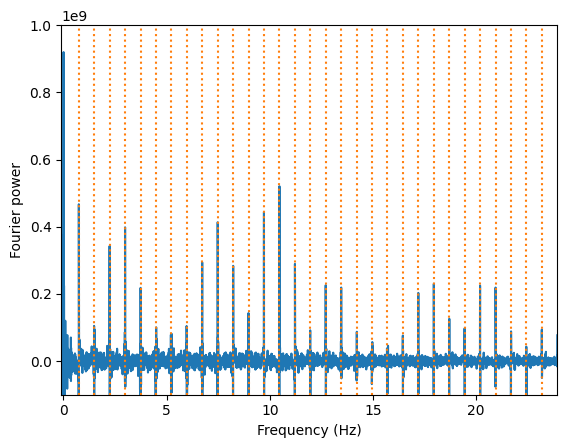

In [4]:
# just a standard FFT
fft = np.fft.rfft(ts)[1:]
xf = np.fft.rfftfreq(n=ts.size, d=tsamp)[1:]
plt.plot(xf, fft)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Fourier power")
# from literature; as a check
p0 = 1.3373
f0 = 1 / p0
# plot harmonics
for i in range(1, 32):
    plt.axvline(i * f0, color="tab:orange", ls=":")
plt.xlim(-0.1, f0 * 32)
plt.ylim(-0.1e9, 1e9)

plt.show()

(-100000000.0, 1000000000.0)

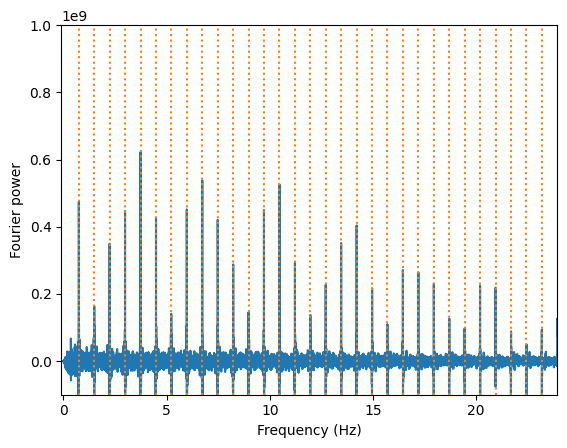

In [5]:
# a zero-padded FFT (adding zeroes at the end; could infinitely do this, but cost is compute)
zero_padded = np.append(norm, np.zeros_like(norm))
fft = np.fft.rfft(zero_padded)[1:]
xf = np.fft.rfftfreq(n=zero_padded.size, d=tsamp)[1:]
plt.plot(xf, fft)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Fourier power")
p0 = 1.3373
f0 = 1 / p0

#plot harmonics
for i in range(1, 32):
    plt.axvline(i * f0, color="tab:orange", ls=":")
plt.xlim(-0.1, f0 * 32)
plt.ylim(-0.1e9, 1e9)

Text(0, 0.5, 'Fourier power')

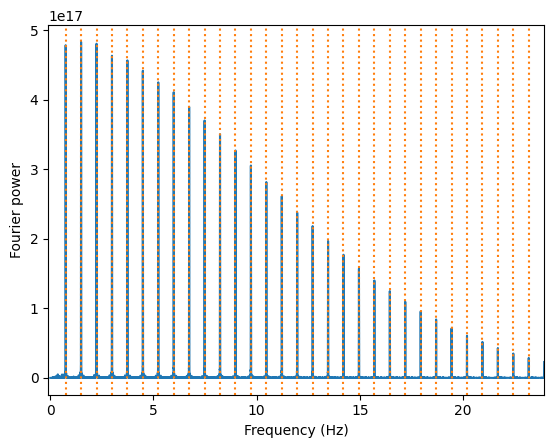

In [6]:
# interbinning; see the pulsar handbook
# the idea here is to catch when the FFT bins do not match well with where the actual power in the FT is
interbinning = np.max(np.vstack((np.abs(fft[:-2] + fft[1:-1]) ** 2 / 2,
    np.abs(fft[1:-1]) ** 2, np.abs(fft[1:-1] + fft[2:]) ** 2 / 2)), axis=0)
plt.plot(xf[1:-1], interbinning)
plt.xlim(-0.1, f0 * 32)
# plot harmonics
for i in range(1, 32):
    plt.axvline(i * f0, color="tab:orange", ls=":")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Fourier power")

Text(0.5, 0, 'Phase')

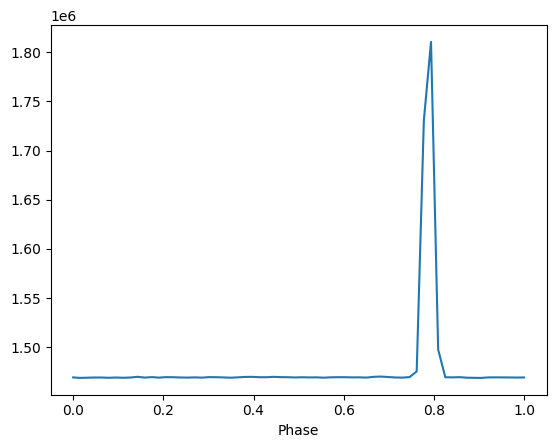

In [7]:
# plot power
# here's a probably optimal way of calculating `nbin` from Cees:
# int(2 ** np.floor(np.log2(p0 / tsamp)))
nbin = 64

# calculate pulse phase for each time step
phase = np.mod(t / p0, 1.0)

# calculate bin to add timestep to
ibin = (nbin * phase).astype("int")

data_sum = np.zeros(nbin)
data_count = np.zeros(nbin)

# sum data and sum counts in each bin
np.add.at(data_sum, ibin, ts)
np.add.at(data_count, ibin, 1.0)

# average in each bin
pulse_profile = data_sum / data_count

# plot profile
xt = np.linspace(0, 1, nbin)
plt.plot(xt, pulse_profile)
plt.xlabel("Phase")

/var/folders/g4/9xmh6cjn4zn7r24hvcfswgz1wj7pk0/T/ipykernel_58684/4109224748.py:21: RuntimeWarning: invalid value encountered in divide
  data = data_sum / data_count


Text(0.5, 0, 'Phase')

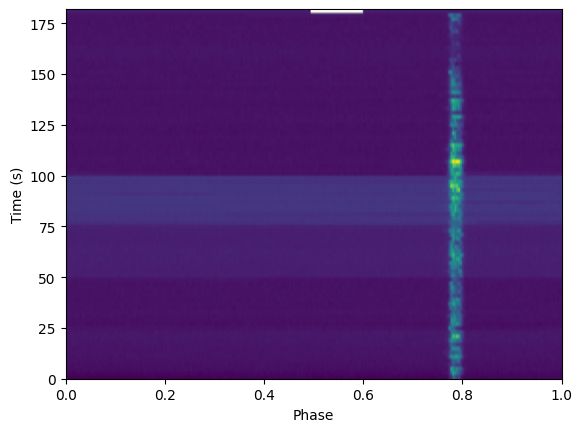

In [8]:
# create a dynamic profile
tsub = 2.0
tmax = np.max(t)
nsub = int(np.ceil(tmax / tsub))

fbin = p0 / tsamp
nbin = int(2 ** np.floor(np.log2(fbin)))

data_sum = np.zeros((nsub, nbin))
data_count = np.zeros((nsub, nbin))

phase = np.mod(t / p0, 1.0)

ibin = (nbin * phase).astype("int")

isub = (t / tsub).astype("int")

np.add.at(data_sum, (isub, ibin), ts)
np.add.at(data_count, (isub, ibin), 1.0)

data = data_sum / data_count

plt.imshow(data, origin="lower", aspect="auto", extent=[0, 1, 0, nsub * tsub])
plt.ylabel("Time (s)")
plt.xlabel("Phase")

In [11]:
# read metadata from .inf files
import glob

metadata_fnames = glob.glob("./*.inf")
mjds = np.empty(len(metadata_fnames))
for i, metadata_fname in enumerate(metadata_fnames):
    with open(metadata_fname, "r") as f:
        metadata = f.readlines()
        for line in metadata:
            if line.startswith(" Epoch"):
                mjds[i] = float(line.split("=")[-1])
                continue

print(mjds)

[56667.6425011]
